<a href="https://colab.research.google.com/github/xwx-codingweb/XIA_DSPN_S26/blob/master/ExerciseSubmissions/09_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (1 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [24]:
getwd()
list.files()

lex_path <- list.files("DSPN_CourseNotebook", pattern = "LexicalData_withIncorrect\\.csv$",
                       recursive = TRUE, full.names = TRUE)
items_path <- list.files("DSPN_CourseNotebook", pattern = "Items\\.csv$",
                         recursive = TRUE, full.names = TRUE)

lex_path
items_path

library(tidyverse)

lex <- read.csv(lex_path[1], stringsAsFactors = FALSE)
items <- read.csv(items_path[1], stringsAsFactors = FALSE)

head(lex)
head(items)

[1] "/content"

[1] "DSPN_CourseNotebook" "sample_data"

[1] "DSPN_CourseNotebook/book/exercises/lexDat/LexicalData_withIncorrect.csv"

[1] "DSPN_CourseNotebook/book/exercises/lexDat/Items.csv"

,X,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>
1,1,157,1,1,710,browse,false,-0.437,1
2,2,67,1,1,"1,094",refrigerant,false,0.825,1
3,3,120,1,1,587,gaining,false,-0.645,1
4,4,21,1,1,984,cheerless,false,0.025,1
5,5,236,1,1,577,pattered,false,-0.763,1
6,6,236,2,1,715,conjures,false,-0.364,1


,Occurrences,Word,Length,Freq_HAL,Log_Freq_HAL
,<int>,<chr>,<int>,<chr>,<dbl>
1,1,synergistic,11,284,5.649
2,1,synonymous,10,951,6.858
3,1,syntactical,11,114,4.736
4,1,synthesis,9,"6,742",8.816
5,1,synthesized,11,"2,709",7.904
6,1,synthesizer,11,"1,390",7.237


In [28]:

# Join word characteristics onto lexical data
fdata <- lex %>%
  left_join(items %>% select(Word, Length, Log_Freq_HAL),
            by = c("D_Word" = "Word")) %>%
  drop_na()

head(fdata)

,X,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Length,Log_Freq_HAL
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,1,157,1,1,710,browse,false,-0.437,1,6,8.856
2,2,67,1,1,"1,094",refrigerant,false,0.825,1,11,4.644
3,3,120,1,1,587,gaining,false,-0.645,1,7,8.304
4,4,21,1,1,984,cheerless,false,0.025,1,9,2.639
5,5,236,1,1,577,pattered,false,-0.763,1,8,1.386
6,6,236,2,1,715,conjures,false,-0.364,1,8,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

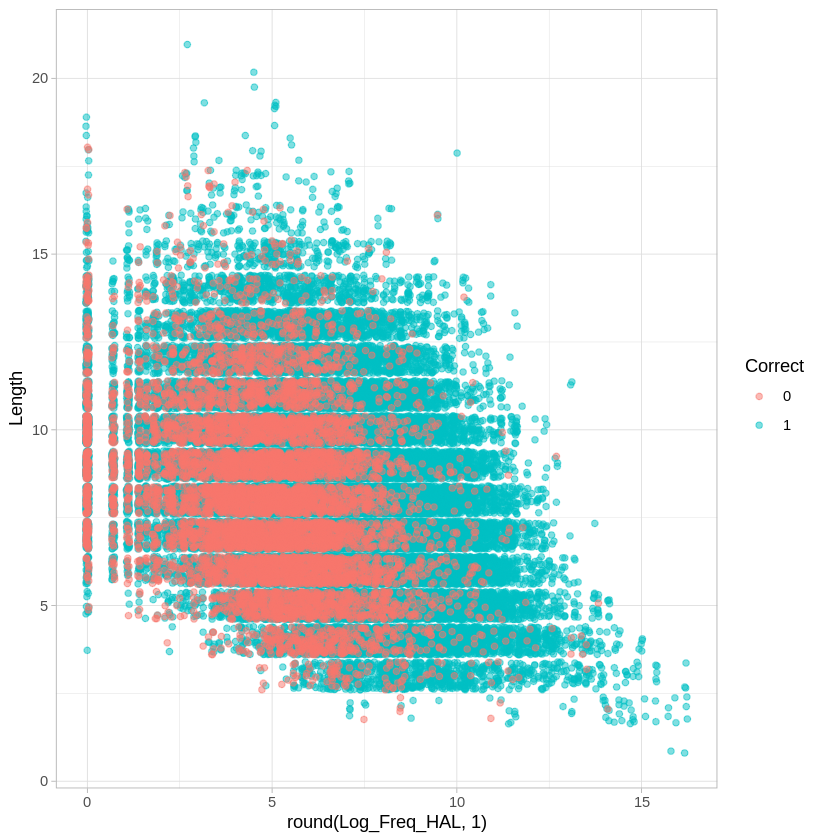

In [33]:
fdata$Correct <- as.factor(fdata$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(fdata,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

> Higher frequency words tend to have more correct responses, while lower frequency words show more incorrect responses.

> There is substantial overlap between correct and incorrect responses, suggesting the classes are not perfectly separable.

---
## 3. Logistic Regression: Fitting the model (2 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [35]:
# WRITE YOUR CODE HERE
log_fit <- glm(Correct ~ Length * Log_Freq_HAL, data = fdata, family = binomial)
summary(log_fit)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = binomial, 
    data = fdata)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> *Write your response here*
>

---
## 4. Interpreting predictions from the model (3 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [36]:
# WRITE YOUR CODE HERE

# Predicted probability of "Correct" (or of level 1 if coded 0/1)
p_hat <- predict(log_fit, type = "response")

# Convert to class prediction using 0.5 threshold
pred <- ifelse(p_hat >= 0.5, 1, 0)

cm <- table(Predicted = pred, Actual = fdata$Correct)
acc <- mean(pred == fdata$Correct)

cm
acc

         Actual
Predicted     0     1
        0    13    44
        1  7966 62566

[1] 0.8865262

Did the model do well at predicting lexical decision correctness? Why or why not?

> *Write your response here*  
>

## 5. QDA (3 points)

Load in the `MASS` library and fit a QDA model to the data set. The predictors are still `Length`, `Log_Freq_HAL`, and their interaction, just like the logistic regression model you just ran, and the dependent variable is still `Correct`.

*Hint: see the Classifiers tutorial.*

In [37]:
# WRITE YOUR CODE HERE
library(MASS)

qda_fit <- qda(Correct ~ Length * Log_Freq_HAL, data = fdata)
qda_fit


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




Call:
qda(Correct ~ Length * Log_Freq_HAL, data = fdata)

Prior probabilities of groups:
        0         1 
0.1130346 0.8869654 

Group means:
    Length Log_Freq_HAL Length:Log_Freq_HAL
0 8.047124     4.932123            37.95260
1 7.979971     6.444849            49.34219

Now look at how well the predicted `Correct` values compare with actual `Correct` values for the whole data set. Output a confusion matrix and overall prediction accuracy.

In [38]:
# WRITE YOUR CODE HERE
qda_pred <- predict(qda_fit, fdata)$class

cm_qda <- table(Predicted = qda_pred, Actual = fdata$Correct)
cm_qda

acc_qda <- mean(qda_pred == fdata$Correct)
acc_qda


         Actual
Predicted     0     1
        0   455  1647
        1  7524 60963

[1] 0.8700789

How does QDA prediction performance differ from that of logistic regression?

> *Write your response here*
>

**DUE:** 5pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

# Task
Load data from "LexicalData_withIncorrect.csv" and "Items.csv", join them by 'Word', drop NAs, and display the head.

## Load and format data

### Subtask:
Load data from 'LexicalData_withIncorrect.csv' and 'Items.csv', join them by 'Word', drop NAs, and display the head.


## Summary:

### Data Analysis Key Findings
The initial step involved successfully loading two datasets, 'LexicalData_withIncorrect.csv' and 'Items.csv'. These datasets were then joined based on the common column 'Word', and any rows containing missing values were removed, ensuring a clean and integrated dataset for subsequent analysis.

### Insights or Next Steps
*   After the successful loading and initial cleaning of the data, the next step should focus on performing exploratory data analysis (EDA) to understand the distributions, relationships, and characteristics of the combined dataset.
*   Verify the integrity and correctness of the join operation and the impact of dropping NA values to ensure the resulting dataset is suitable for the intended analysis.
